# Conditional Workflow 

In [74]:
from langgraph.graph import StateGraph , START , END 
from typing  import TypedDict , Literal 

### Schema 

In [75]:
class Quadstate(TypedDict):
    a : int 
    b : int 
    c : int 

    equation : str 
    discriminant : str 

    result :    str 

### Define Graph 

In [76]:
graph = StateGraph(Quadstate)

#### Functions 

1. Show Equation 

In [77]:
def show_equation(state:Quadstate):
    equation = f"({state['a']}x^2) + ({state['b']}x) + ({state['c']}) = 0"
    return {"equation" : equation}

2. Calculate Discriminant

In [78]:
def cal_Discriminant(state:Quadstate):
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = b**2 - 4*a*c
    return {"discriminant" : discriminant}

3. Find Roots

In [79]:
def real_root(state:Quadstate):
    b = state['b']
    d = state['discriminant']
    a = state['a']

    root_1 = -b+d**0.5/(2*a)
    root_2 = -b-d**0.5/(2*a)

    result = f"The root is {root_1} and {root_2}"
    return {"result" : result}
    
def same_real_root(state:Quadstate):
    b = state['b']
    a = state['a']

    root = -b/(2*a)

    result = f"The root is {root}"
    return {"result" : result}

def not_real_root(state:Quadstate):
    result = f"There is no real root"
    return {"result" : result}

In [80]:
#Check Condtion 

def check_condition(state:Quadstate)-> Literal["real_root" , "same_real_root" , "not_real_root"]:
    d = state['discriminant'] 
    if d > 0 :
        return "real_root"
    elif d == 0 :
        return "same_real_root"
    else :
        return "not_real_root"

#### Nodes 

In [81]:
graph.add_node("show_equation" , show_equation)
graph.add_node("cal_Discriminant" , cal_Discriminant)
graph.add_node("real_root" , real_root)
graph.add_node("same_real_root" , same_real_root)
graph.add_node("not_real_root" , not_real_root)



### Edges

In [82]:
graph.add_edge(START, "show_equation")
graph.add_edge("show_equation" , "cal_Discriminant")
graph.add_conditional_edges("cal_Discriminant",check_condition)

graph.add_edge('real_root',END)
graph.add_edge('same_real_root',END)
graph.add_edge('not_real_root',END)


workflow = graph.compile()


In [83]:
if __name__ == "__main__":
    initial_state = {
        "a" : 1,
        "b" : -3,
        "c" : 2
    }
    result = workflow.invoke(initial_state)
    print(result)

{'a': 1, 'b': -3, 'c': 2, 'equation': '(1x^2) + (-3x) + (2) = 0', 'discriminant': 1, 'result': 'The root is 3.5 and 2.5'}


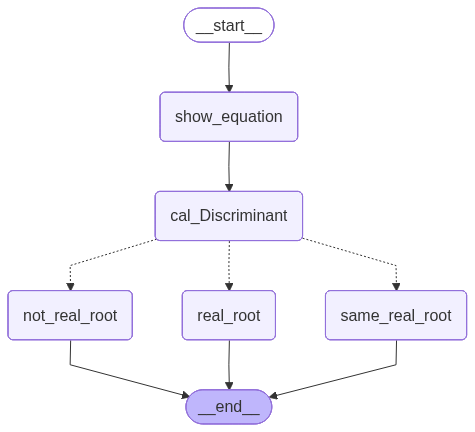

In [84]:
workflow